# HATR cross-framework — Qualità di regressione

Confronto di `HoeffdingAdaptiveTreeRegressor` in River e CapyMOA su 4 dataset in prequential evaluation, con due configurazioni: deterministica (`mean`, no bootstrap) per misurare la consistenza, e default (`adaptive`, bootstrap) per la qualità realistica.

## Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jpype
import jpype.config
jpype.config.destroy_jvm = False

HATR_JAR = os.path.normpath(os.path.join(os.getcwd(), '..', 'implementation',
    'hatr-moa', 'target',
    'hoeffding-adaptive-tree-regressor-moa-1.0-SNAPSHOT.jar'))
assert os.path.exists(HATR_JAR), f"JAR non trovato: {HATR_JAR}\ncompilare: cd implementation/hatr-moa && mvn -o package -DskipTests"

if jpype.isJVMStarted():
    print('JVM già avviata — Kernel -> Restart & Run All')
else:
    os.environ["CAPYMOA_JVM_ARGS"] = "-Xmx8g -Xss10M -XX:ErrorFile=/dev/null"
    jpype.addClassPath(HATR_JAR)

from capymoa.datasets import Bike, Fried
from capymoa.stream.generator import HyperPlaneRegression

import utils   # importato dopo JVM: gestisce sys.path, capymoa, river, hatr_capymoa

print("Setup OK — JVM avviata, HATR caricato, River e CapyMOA importati")

Setup OK — JVM avviata, HATR caricato, River e CapyMOA importati


## Dataset

In [2]:
MAX_INSTANCES = 17000
SYN_N, SYN_DRIFT = 17000, 5000

datasets = {}
datasets["Synthetic"] = utils.make_synthetic(n=SYN_N, drift_at=SYN_DRIFT)
datasets["Bike"]      = utils.materialize_stream(Bike(), MAX_INSTANCES)
datasets["Fried"]     = utils.materialize_stream(Fried(), MAX_INSTANCES)
datasets["Hyper"]     = utils.materialize_stream(
    HyperPlaneRegression(instance_random_seed=1, number_of_attributes=10,
                         number_of_drifting_attributes=2, magnitude_of_change=0.001,
                         noise_percentage=5),
    MAX_INSTANCES)

for name, (X, y, schema) in datasets.items():
    print(f"{name:<10} n={len(X):>6}  feat={X.shape[1]:>2}  y∈[{y.min():.2f}, {y.max():.2f}]")

Synthetic  n= 17000  feat= 5  y∈[-14.29, 15.55]
Bike       n= 17000  feat=12  y∈[1.00, 977.00]
Fried      n= 17000  feat=10  y∈[-1.23, 30.05]
Hyper      n= 17000  feat=10  y∈[93.98, 677.42]


## Parametri

In [3]:
BASE = dict(grace_period=200, delta=1e-7, tau=0.05, model_selector_decay=0.95,
            drift_window_threshold=300, switch_significance=0.05,
            min_samples_split=5, adwin_delta=0.002, learning_ratio=0.01, seed=0)

CONFIGS = {
    "deterministic (mean, no-bootstrap)": dict(leaf_prediction="mean",     bootstrap_sampling=False),
    "default (adaptive, bootstrap)":      dict(leaf_prediction="adaptive", bootstrap_sampling=True),
}

SCALE = True
SKIP  = 50

## Esecuzione

In [9]:
rows = []
preds_cache = {}   # (dataset, config) -> (yt, river_pred, capy_pred)

CFG = CONFIGS["default (adaptive, bootstrap)"]
# warmup JVM: evita che il JIT di HotSpot penalizzi il primo dataset (Bike)
_w_X, _w_y, _w_schema = next(iter(datasets.values()))
utils.prequential_eval(_w_X[:10000], _w_y[:10000], 'capy', CFG, BASE, schema=_w_schema, scale=SCALE)

for ds_name, (X, y, schema) in datasets.items():
    for cfg_name, cfg in CONFIGS.items():
        rp, *_ = utils.prequential_eval(X, y, 'river', cfg, BASE, scale=SCALE)
        cp, *_ = utils.prequential_eval(X, y, 'capy', cfg, BASE, schema=schema, scale=SCALE)
        preds_cache[(ds_name, cfg_name)] = (y, rp, cp)
        rows.append(dict(dataset=ds_name, config=cfg_name, framework="River",
                         MAE=utils.mae(y[SKIP:], rp[SKIP:]),
                         RMSE=utils.rmse(y[SKIP:], rp[SKIP:]),
                         R2=utils.r2(y[SKIP:], rp[SKIP:])))
        rows.append(dict(dataset=ds_name, config=cfg_name, framework="CapyMOA",
                         MAE=utils.mae(y[SKIP:], cp[SKIP:]),
                         RMSE=utils.rmse(y[SKIP:], cp[SKIP:]),
                         R2=utils.r2(y[SKIP:], cp[SKIP:])))
        print(f"  {ds_name:<10} | {cfg_name:<32} | done")

results = pd.DataFrame(rows)
print("\nRisultati completi:")
results

  Synthetic  | deterministic (mean, no-bootstrap) | done
  Synthetic  | default (adaptive, bootstrap)    | done
  Bike       | deterministic (mean, no-bootstrap) | done
  Bike       | default (adaptive, bootstrap)    | done
  Fried      | deterministic (mean, no-bootstrap) | done
  Fried      | default (adaptive, bootstrap)    | done
  Hyper      | deterministic (mean, no-bootstrap) | done
  Hyper      | default (adaptive, bootstrap)    | done

Risultati completi:


,dataset,config,framework,MAE,RMSE,R2
0,Synthetic,"deterministic (mean, no-bootstrap)",River,0.9368,1.5271,0.7870
1,Synthetic,"deterministic (mean, no-bootstrap)",CapyMOA,0.9368,1.5271,0.7870
2,Synthetic,"default (adaptive, bootstrap)",River,0.2955,0.5260,0.9747
3,Synthetic,"default (adaptive, bootstrap)",CapyMOA,0.2913,0.5183,0.9755
4,Bike,"deterministic (mean, no-bootstrap)",River,85.4015,123.4328,0.5407
5,Bike,"deterministic (mean, no-bootstrap)",CapyMOA,85.4015,123.4328,0.5407
6,Bike,"default (adaptive, bootstrap)",River,73.0955,113.0011,0.6151
7,Bike,"default (adaptive, bootstrap)",CapyMOA,69.4085,110.8189,0.6298
8,Fried,"deterministic (mean, no-bootstrap)",River,2.4931,3.1209,0.6085
9,Fried,"deterministic (mean, no-bootstrap)",CapyMOA,2.4931,3.1209,0.6085


## Qualità

In [10]:
pivot = results.pivot_table(index=["dataset", "config"], columns="framework",
                            values=["MAE", "RMSE", "R2"])
pivot = pivot.reorder_levels([1, 0], axis=1).sort_index(axis=1)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
pivot

framework                                    CapyMOA                   River  \
                                                 MAE     R2     RMSE     MAE   
dataset   config                                                               
Bike      default (adaptive, bootstrap)      69.4085 0.6298 110.8189 73.0955   
          deterministic (mean, no-bootstrap) 85.4015 0.5407 123.4328 85.4015   
Fried     default (adaptive, bootstrap)       1.8661 0.7690   2.3971  1.8270   
          deterministic (mean, no-bootstrap)  2.4931 0.6085   3.1209  2.4931   
Hyper     default (adaptive, bootstrap)       9.8627 0.9360  17.7371  8.4238   
          deterministic (mean, no-bootstrap) 46.6526 0.3063  58.3844 46.6526   
Synthetic default (adaptive, bootstrap)       0.2913 0.9755   0.5183  0.2955   
          deterministic (mean, no-bootstrap)  0.9368 0.7870   1.5271  0.9368   

framework                                                     
                                                 R2     RMSE  
dataset   config                                              
Bike      default (adaptive, bootstrap)      0.6151 113.0011  
          deterministic (mean, no-bootstrap) 0.5407 123.4328  
Fried     default (adaptive, bootstrap)      0.7770   2.3556  
          deterministic (mean, no-bootstrap) 0.6085   3.1209  
Hyper     default (adaptive, bootstrap)      0.9476  16.0489  
          deterministic (mean, no-bootstrap) 0.3063  58.3844  
Synthetic default (adaptive, bootstrap)      0.9747   0.5260  
          deterministic (mean, no-bootstrap) 0.7870   1.5271

## Grafici

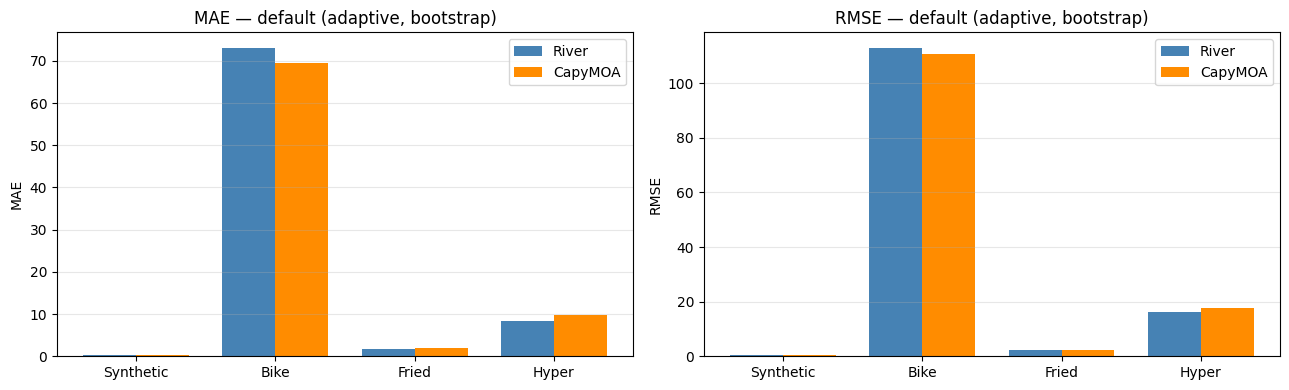

In [11]:
cfg_plot = "default (adaptive, bootstrap)"
sub = results[results.config == cfg_plot]
ds_order = list(datasets.keys())
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, metric in zip(axes, ["MAE", "RMSE"]):
    rv = [sub[(sub.dataset == d) & (sub.framework == "River")][metric].values[0] for d in ds_order]
    cm = [sub[(sub.dataset == d) & (sub.framework == "CapyMOA")][metric].values[0] for d in ds_order]
    xpos = np.arange(len(ds_order)); wbar = 0.38
    ax.bar(xpos - wbar/2, rv, wbar, label="River", color="steelblue")
    ax.bar(xpos + wbar/2, cm, wbar, label="CapyMOA", color="darkorange")
    ax.set_xticks(xpos); ax.set_xticklabels(ds_order)
    ax.set_ylabel(metric); ax.set_title(f"{metric} — {cfg_plot}")
    ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

## Consistenza (deterministico)

In [7]:
cfg_det = "deterministic (mean, no-bootstrap)"
cons = []
for ds_name in datasets.keys():
    yt, rp, cp = preds_cache[(ds_name, cfg_det)]
    d = np.abs(rp - cp)
    corr = np.corrcoef(rp[SKIP:], cp[SKIP:])[0, 1]
    cons.append(dict(dataset=ds_name,
                     corr=corr, max_abs_diff=d.max(), mean_abs_diff=d.mean(),
                     frac_diff_lt_1e6=float(np.mean(d < 1e-6)),
                     MAE_river=utils.mae(yt[SKIP:], rp[SKIP:]),
                     MAE_capy=utils.mae(yt[SKIP:], cp[SKIP:]),
                     dMAE=abs(utils.mae(yt[SKIP:], rp[SKIP:]) - utils.mae(yt[SKIP:], cp[SKIP:]))))
cons_df = pd.DataFrame(cons)
print("Consistenza (mean, no bootstrap):")
cons_df

Consistenza (mean, no bootstrap):


,dataset,corr,max_abs_diff,mean_abs_diff,frac_diff_lt_1e6,MAE_river,MAE_capy,dMAE
0,Synthetic,1.0000,0.0000,0.0000,1.0000,0.9368,0.9368,0.0000
1,Bike,1.0000,0.0000,0.0000,1.0000,85.4015,85.4015,0.0000
2,Fried,1.0000,0.0000,0.0000,1.0000,2.4931,2.4931,0.0000
3,Hyper,1.0000,0.0000,0.0000,1.0000,46.6526,46.6526,0.0000


## Discussione

**Modalità deterministica (`mean`, no bootstrap).** Le implementazioni condividono lo stesso algoritmo; ci si aspettano predizioni identiche (corr ≈ 1, delta_MAE ≈ 0).

**Modalità default (`adaptive` + bootstrap).** Le RNG divergono (Python MT vs `java.util.Random`): le predizioni puntuali non coincidono, ma MAE/RMSE aggregati restano vicini. Per valutare la qualità reale è questo il confronto corretto.

**Standardizzazione.** `SCALE=True` applica lo stesso `StandardScaler` online a entrambi i lati; non introduce asimmetrie.